# Exercises XP: Time Series Analysis with an LSTM - Household Power Consumption

Week 11, Day 2

**Dataset:** [Individual household electric power consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption) (UCI, id 235): measurements taken **every minute** in a house near Paris between December 2006 and November 2010 (about 2 million rows).

| Column | Description |
|---|---|
| Date, Time | date (dd/mm/yyyy) and time (hh:mm:ss) |
| Global_active_power | household global minute-averaged active power (kW) |
| Global_reactive_power | household global minute-averaged reactive power (kW) |
| Voltage | minute-averaged voltage (V) |
| Global_intensity | household global minute-averaged current intensity (A) |
| Sub_metering_1 | kitchen (dishwasher, oven, microwave), Wh |
| Sub_metering_2 | laundry room (washing machine, tumble-drier, fridge, light), Wh |
| Sub_metering_3 | electric water heater and air conditioner, Wh |

> ⚠️ In Colab, turn on the GPU: *Runtime → Change runtime type → T4 GPU*. The notebook also runs on CPU (a bit more slowly).

## Part 1: Data Import and Initial Exploration

In [1]:
!pip install -q ucimlrepo

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_style('whitegrid')
pd.set_option('display.width', 120)

In [3]:
# fetch dataset
individual_household_electric_power_consumption = fetch_ucirepo(id=235)

# data (as pandas dataframes)
X = individual_household_electric_power_consumption.data.features
y = individual_household_electric_power_consumption.data.targets

# metadata
print(individual_household_electric_power_consumption.metadata)

# variable information
print(individual_household_electric_power_consumption.variables)

{'uci_id': 235, 'name': 'Individual Household Electric Power Consumption', 'repository_url': 'https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption', 'data_url': 'https://archive.ics.uci.edu/static/public/235/data.csv', 'abstract': 'Measurements of electric power consumption in one household with a one-minute sampling rate over a period of almost 4 years. Different electrical quantities and some sub-metering values are available.', 'area': 'Physics and Chemistry', 'tasks': ['Regression', 'Clustering'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 2075259, 'num_features': 9, 'feature_types': ['Real'], 'demographics': [], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2006, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C58K54', 'creators': ['Georges Hebrail', 'Alice Berard'], 'intro_paper': None, 'additional_info': {'summary': 'This archiv

In [4]:
print("Targets:", y)  # this dataset has no target column: all the variables are in X
df = X.copy()
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)

Targets: None


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


Shape: (2075259, 9)
Date                         str
Time                         str
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


The dataset has **2,075,259 rows** (one per minute over almost 4 years) and **9 columns**. The data types show a problem: all measurement columns except `Sub_metering_3` are of type **object** (text) instead of numbers. This is because missing measurements are written as the character **`"?"`** in the original file, so pandas cannot read these columns as numbers.

In [5]:
# Build a datetime index from the Date and Time columns
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time']).set_index('Datetime')

# Convert the measurement columns to numbers ("?" becomes NaN)
print("Number of '?' per column:")
print((df == '?').sum())
df = df.apply(pd.to_numeric, errors='coerce')

print("\nData types after conversion:")
print(df.dtypes)
print("Shape:", df.shape, "| from", df.index.min(), "to", df.index.max())
display(df.describe().round(3))

Number of '?' per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3               0
dtype: int64



Data types after conversion:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
Shape: (2075259, 7) | from 2006-12-16 17:24:00 to 2010-11-26 21:02:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2049280.000,2049280.000,2049280.00,2049280.000,2049280.000,2049280.000,2049280.000
mean,1.092,0.124,240.84,4.628,1.122,1.299,6.458
std,1.057,0.113,3.24,4.444,6.153,5.822,8.437
min,0.076,0.000,223.20,0.200,0.000,0.000,0.000
25%,0.308,0.048,238.99,1.400,0.000,0.000,0.000
50%,0.602,0.100,241.01,2.600,0.000,0.000,1.000
75%,1.528,0.194,242.89,6.400,0.000,1.000,17.000
max,11.122,1.390,254.15,48.400,88.000,80.000,31.000


## Part 2: Handling Missing Values

In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nColumns with missing values: {missing[missing > 0].index.tolist()}")
print(f"Rows with at least one missing value: {df.isnull().any(axis=1).sum():,} ({df.isnull().any(axis=1).mean():.2%})")

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Columns with missing values: ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
Rows with at least one missing value: 25,979 (1.25%)


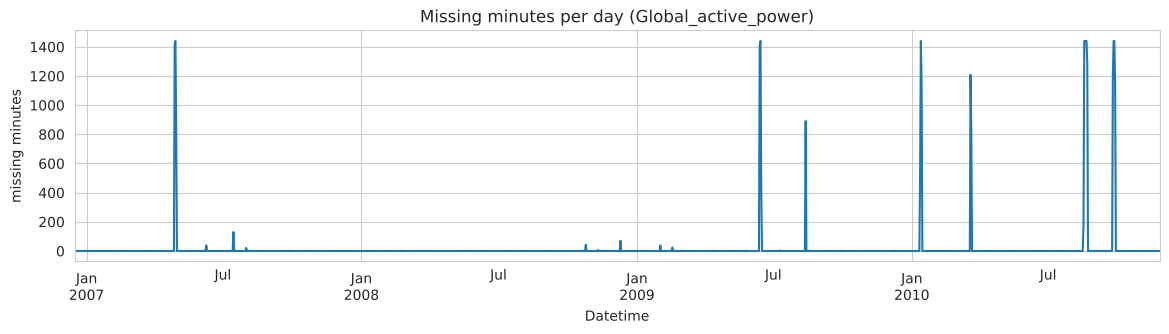

Days with more than 12 hours missing: 19


In [7]:
# Where are the missing values? (number of missing minutes per day)
missing_per_day = df['Global_active_power'].isnull().resample('D').sum()
plt.figure(figsize=(14, 3))
missing_per_day.plot()
plt.title('Missing minutes per day (Global_active_power)')
plt.ylabel('missing minutes')
plt.show()
print("Days with more than 12 hours missing:", (missing_per_day > 720).sum())

In [8]:
# Fill the missing values with the mean of each column
df = df.fillna(df.mean())

print("Missing values after filling:")
print(df.isnull().sum())
assert df.isnull().sum().sum() == 0

Missing values after filling:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


All 7 measurement columns have exactly the same **25,979 missing rows (1.25%)**: when a measurement is missing, the whole minute is missing (sensor or recording outage). They are concentrated in a few blocks of consecutive days (power or logging outages), not spread randomly.

As requested, we replace them by the **mean of each column**. It is simple and keeps all rows, but it is not perfect for a time series: a long outage becomes a flat line at the average value, and daily patterns are lost during these periods. Better options for time series would be a forward fill / interpolation for short gaps, or filling with the value at the same time of the previous day/week for long gaps. Since only 1.25% of the data is concerned, the impact on the analysis is small.

## Part 3: Data Visualization

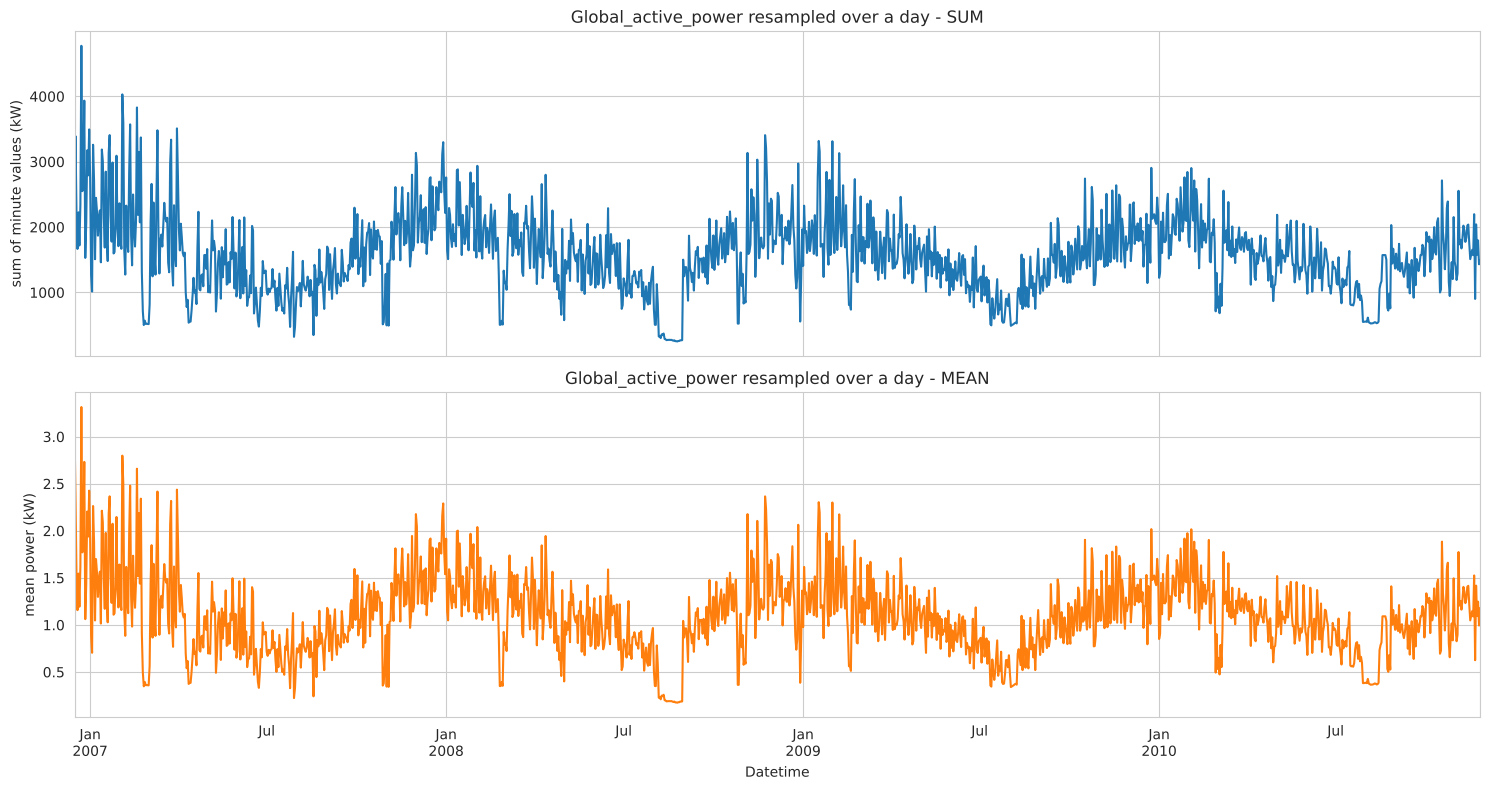

Daily energy consumption ≈ sum / 60 (kWh):
count    1442.00
mean       26.18
std         9.92
min         4.17
25%        19.85
50%        25.98
75%        31.50
max        79.56
Name: sum, dtype: float64


In [9]:
daily_power = df['Global_active_power'].resample('D').agg(['sum', 'mean'])

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
daily_power['sum'].plot(ax=axes[0], color='tab:blue')
axes[0].set_title('Global_active_power resampled over a day - SUM')
axes[0].set_ylabel('sum of minute values (kW)')
daily_power['mean'].plot(ax=axes[1], color='tab:orange')
axes[1].set_title('Global_active_power resampled over a day - MEAN')
axes[1].set_ylabel('mean power (kW)')
plt.tight_layout()
plt.show()

print("Daily energy consumption ≈ sum / 60 (kWh):")
print((daily_power['sum'] / 60).describe().round(2))

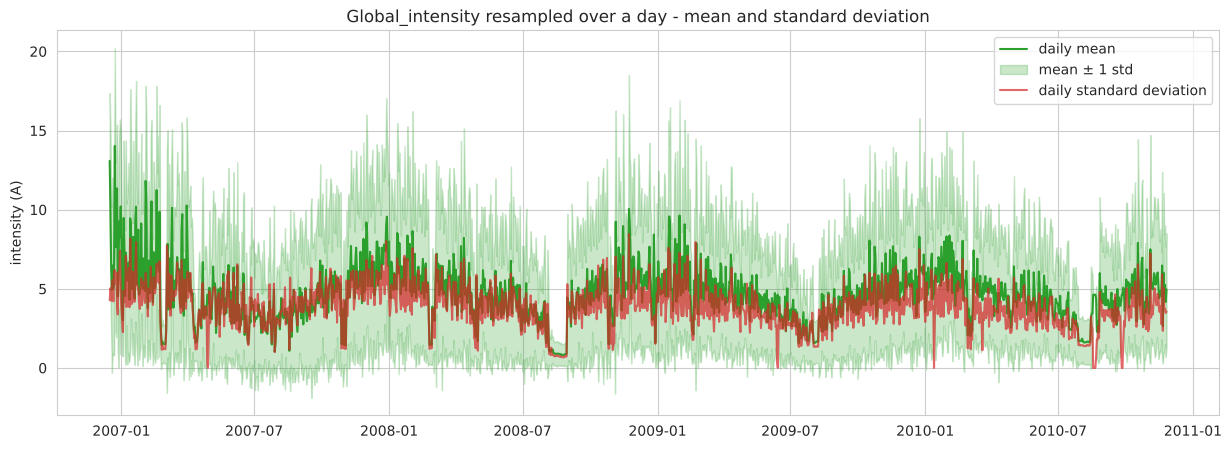

In [10]:
daily_intensity = df['Global_intensity'].resample('D').agg(['mean', 'std'])

plt.figure(figsize=(15, 5))
plt.plot(daily_intensity.index, daily_intensity['mean'], label='daily mean', color='tab:green')
plt.fill_between(daily_intensity.index,
                 daily_intensity['mean'] - daily_intensity['std'],
                 daily_intensity['mean'] + daily_intensity['std'],
                 alpha=0.25, color='tab:green', label='mean ± 1 std')
plt.plot(daily_intensity.index, daily_intensity['std'], label='daily standard deviation', color='tab:red', alpha=0.7)
plt.title('Global_intensity resampled over a day - mean and standard deviation')
plt.ylabel('intensity (A)')
plt.legend()
plt.show()

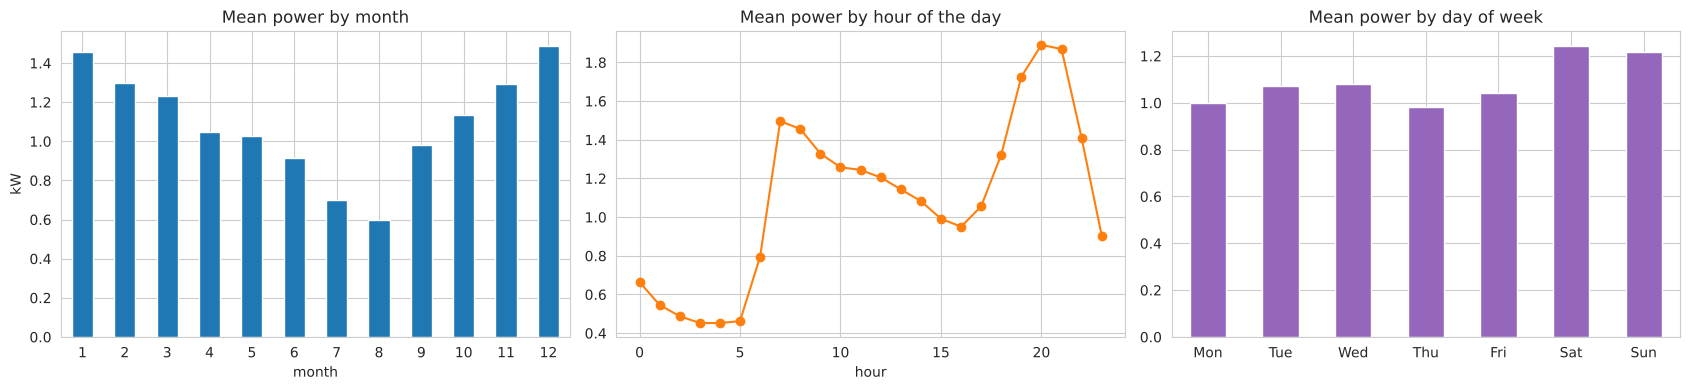

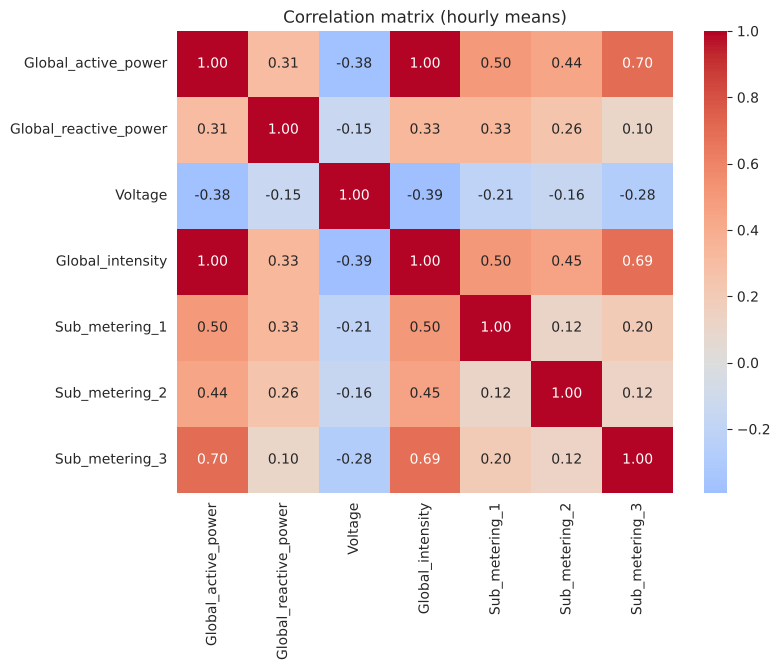

In [11]:
# Extra views: seasonality by month, by hour of the day and by day of week, and correlations
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
df['Global_active_power'].groupby(df.index.month).mean().plot(kind='bar', ax=axes[0], color='tab:blue', rot=0)
axes[0].set_title('Mean power by month'); axes[0].set_xlabel('month'); axes[0].set_ylabel('kW')
df['Global_active_power'].groupby(df.index.hour).mean().plot(ax=axes[1], marker='o', color='tab:orange')
axes[1].set_title('Mean power by hour of the day'); axes[1].set_xlabel('hour')
df['Global_active_power'].groupby(df.index.dayofweek).mean().plot(kind='bar', ax=axes[2], color='tab:purple', rot=0)
axes[2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[2].set_title('Mean power by day of week'); axes[2].set_xlabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.resample('h').mean().corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (hourly means)')
plt.show()

**What the plots show:**
- **Strong yearly seasonality:** consumption is high in winter and low in summer. The mean power goes from about **1.46–1.49 kW in December–January** down to **0.6 kW in August** (heating and lighting in winter, holidays in August). The daily sum and mean curves follow exactly the same shape, because the sum is just the mean × 1,440 minutes. On average the household uses about **26 kWh per day** (from 4 to 80 kWh).
- **Strong daily pattern:** consumption is minimal at night (about 0.45 kW between 3 and 5 am), has a **morning peak around 7–8 am (1.5 kW)** and a larger **evening peak around 8–9 pm (1.9 kW)**.
- **Weekly pattern:** consumption is about 15–20% higher on **Saturdays and Sundays** (1.22–1.25 kW vs 1.0–1.08 kW on weekdays), when the occupants are at home.
- **Global_intensity** (current in A) follows the same pattern as the active power: a daily mean of about 4.6 A and a high daily **standard deviation (≈ 3.8 A)**, which shows that within a single day the consumption varies a lot (appliances turned on and off). The days where the standard deviation drops to 0 are the long outages filled with the mean value (Part 2).
- **Correlations:** Global_intensity is almost perfectly correlated with Global_active_power (r = 1.00, since power = voltage × current and the voltage is nearly constant). Sub_metering_3 (water heater and air conditioning) is the sub-meter most correlated with the total consumption (0.70). Voltage is slightly negatively correlated (−0.38): the voltage drops a little when the household draws more current.
- The first two weeks (December 2006) are unusually high, which explains the higher mean for 2006 (1.9 kW vs about 1.07 kW for the other years).

## Part 4: Data Preprocessing for LSTM

**Goal:** predict the **average Global_active_power of the next hour** from the measurements of the **previous 24 hours**.

- We work on **hourly averages**: 2 million minute-level rows would make training very slow, and minute values are extremely noisy. Hourly resampling gives about 34,600 time steps that still contain the daily and weekly patterns.
- The split is **chronological** (first 80% for training, last 20% for testing): we must never train on the future to predict the past.
- The values are **normalised to [0, 1]** with a `MinMaxScaler` fitted **on the training set only**, so that no information from the test period leaks into the model.

In [12]:
from sklearn.preprocessing import MinMaxScaler

hourly = df.resample('h').mean()
print("Hourly dataset:", hourly.shape)

features = hourly.columns.tolist()
target_col = features.index('Global_active_power')

# Chronological split 80 / 20
split = int(len(hourly) * 0.8)
train_df, test_df = hourly.iloc[:split], hourly.iloc[split:]
print("Train:", train_df.index.min(), "->", train_df.index.max(), train_df.shape)
print("Test :", test_df.index.min(), "->", test_df.index.max(), test_df.shape)

# Normalise (fit on the training set only)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)
print("Scaled train range:", train_scaled.min().round(3), "-", train_scaled.max().round(3))

Hourly dataset: (34589, 7)
Train: 2006-12-16 17:00:00 -> 2010-02-11 15:00:00 (27671, 7)
Test : 2010-02-11 16:00:00 -> 2010-11-26 21:00:00 (6918, 7)
Scaled train range: 0.0 - 1.0


In [13]:
LOOKBACK = 24  # hours of history used to make one prediction

def make_sequences(data, lookback=LOOKBACK, target=target_col):
    """Turn a (time, features) array into LSTM samples of shape (samples, lookback, features) and next-hour targets."""
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i - lookback:i])
        y_seq.append(data[i, target])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = make_sequences(train_scaled)
# For the test set, prepend the last 24 training hours so that the first test hour can be predicted
X_test, y_test = make_sequences(np.vstack([train_scaled[-LOOKBACK:], test_scaled]))

print("X_train:", X_train.shape, "(samples, timesteps, features) | y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test:", y_test.shape)

X_train: (27647, 24, 7) (samples, timesteps, features) | y_train: (27647,)
X_test : (6918, 24, 7) | y_test: (6918,)


The LSTM expects a 3D input **(samples, timesteps, features)**: each sample is a window of **24 consecutive hours × 7 features**, and its target is the scaled Global_active_power of the following hour.

## Part 5: Building an LSTM Model

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),   # first LSTM layer returns the whole sequence for the next layer
    Dropout(0.2),
    LSTM(32),                          # second LSTM layer returns only its last hidden state
    Dropout(0.2),
    Dense(1),                          # regression output: next-hour power (scaled)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

TensorFlow: 2.21.0 | GPU: []


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

**Architecture choices:**
- **Two stacked LSTM layers (64 then 32 units):** LSTMs keep a memory of the previous time steps, which lets them learn daily patterns (morning and evening peaks) and recent trends. The first layer returns its full output sequence so that the second layer can build higher-level temporal features.
- **Dropout (0.2)** after each LSTM layer limits overfitting.
- **Dense(1) with a linear activation:** this is a regression problem (a power in kW), so the output is a single unbounded number.
- **Loss = mean squared error (MSE)**, the standard loss for regression, which strongly penalises large errors; **optimizer = Adam** (learning rate 0.001), with the **MAE** tracked as an easier-to-read metric.

## Part 6: Training and Evaluating the LSTM Model

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,   # last 10% of the training windows (chronologically) used for validation
    shuffle=True,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/30


389/389 - 9s - 24ms/step - loss: 0.0141 - mae: 0.0890 - val_loss: 0.0103 - val_mae: 0.0737


Epoch 2/30


389/389 - 6s - 16ms/step - loss: 0.0101 - mae: 0.0725 - val_loss: 0.0091 - val_mae: 0.0697


Epoch 3/30


...

389/389 - 6s - 15ms/step - loss: 0.0073 - mae: 0.0595 - val_loss: 0.0077 - val_mae: 0.0617


Epoch 27/30


389/389 - 6s - 15ms/step - loss: 0.0073 - mae: 0.0592 - val_loss: 0.0077 - val_mae: 0.0615


Epoch 28/30


389/389 - 6s - 15ms/step - loss: 0.0073 - mae: 0.0590 - val_loss: 0.0076 - val_mae: 0.0616


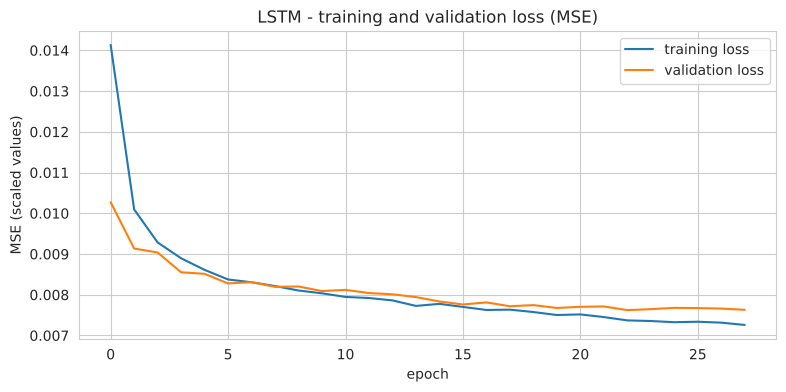

Epochs run: 28 | best validation loss: 0.00762 at epoch 23


In [16]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('LSTM - training and validation loss (MSE)')
plt.xlabel('epoch')
plt.ylabel('MSE (scaled values)')
plt.legend()
plt.show()
print(f"Epochs run: {len(history.history['loss'])} | best validation loss: {min(history.history['val_loss']):.5f} "
      f"at epoch {int(np.argmin(history.history['val_loss'])) + 1}")

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss (MSE, scaled): {test_loss:.5f} | test MAE (scaled): {test_mae:.5f}")

# Back to kW: invert the scaling of the target column only
def inverse_target(values):
    return values * (scaler.data_max_[target_col] - scaler.data_min_[target_col]) + scaler.data_min_[target_col]

y_pred = inverse_target(model.predict(X_test, verbose=0).ravel())
y_true = inverse_target(y_test)

# Naive baseline: "the next hour will be like the last one"
y_naive = inverse_target(X_test[:, -1, target_col])

results = pd.DataFrame({
    'RMSE (kW)': [np.sqrt(mean_squared_error(y_true, y_pred)), np.sqrt(mean_squared_error(y_true, y_naive))],
    'MAE (kW)': [mean_absolute_error(y_true, y_pred), mean_absolute_error(y_true, y_naive)],
    'R²': [r2_score(y_true, y_pred), r2_score(y_true, y_naive)],
}, index=['LSTM', 'Naive baseline (previous hour)'])
display(results.round(4))
print(f"Mean hourly power on the test period: {y_true.mean():.3f} kW")

Test loss (MSE, scaled): 0.00559 | test MAE (scaled): 0.05154


,RMSE (kW),MAE (kW),R²
LSTM,0.4812,0.3317,0.5576
Naive baseline (previous hour),0.5901,0.3813,0.3349


Mean hourly power on the test period: 1.008 kW


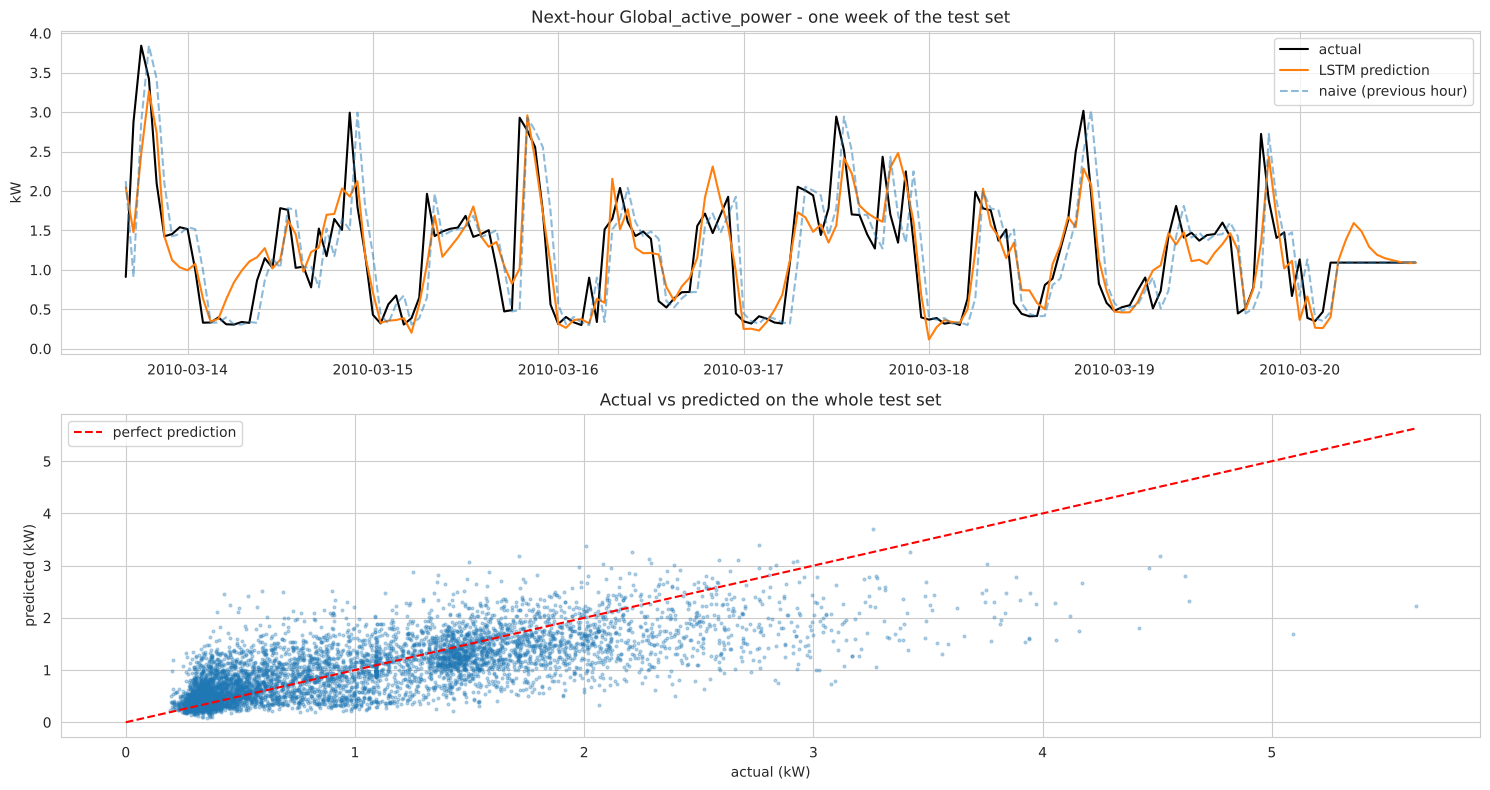

In [18]:
test_index = test_df.index
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
week = slice(24 * 30, 24 * 37)  # one week in the test period
axes[0].plot(test_index[week], y_true[week], label='actual', color='black')
axes[0].plot(test_index[week], y_pred[week], label='LSTM prediction', color='tab:orange')
axes[0].plot(test_index[week], y_naive[week], label='naive (previous hour)', color='tab:blue', alpha=0.5, ls='--')
axes[0].set_title('Next-hour Global_active_power - one week of the test set')
axes[0].set_ylabel('kW')
axes[0].legend()

axes[1].scatter(y_true, y_pred, s=4, alpha=0.3)
lim = [0, max(y_true.max(), y_pred.max())]
axes[1].plot(lim, lim, 'r--', label='perfect prediction')
axes[1].set_xlabel('actual (kW)')
axes[1].set_ylabel('predicted (kW)')
axes[1].set_title('Actual vs predicted on the whole test set')
axes[1].legend()
plt.tight_layout()
plt.show()

## Analysis of the results

**Learning curves:** the training and validation losses decrease together and stay very close (≈ 0.0073 vs 0.0077 at the end): the model is **not overfitting**. The improvement becomes very small after about 15 epochs, and early stopping ended the training after 28 epochs, restoring the best weights (epoch 23).

**Performance on the test set** (February to November 2010, never seen during training):

| Model | RMSE (kW) | MAE (kW) | R² |
|---|---|---|---|
| **LSTM** | **0.481** | **0.332** | **0.558** |
| Naive baseline (same as previous hour) | 0.590 | 0.381 | 0.335 |

- The LSTM predicts the next-hour average power with a mean absolute error of **0.33 kW**, for an average consumption of 1.0 kW over the test period.
- It is clearly better than the naive baseline: **−18% RMSE and −13% MAE**, and it explains 56% of the variance instead of 33%. It has learned the daily rhythm of the house (night-time low, morning and evening peaks) instead of just repeating the last value.
- The one-week plot shows that the LSTM follows the overall daily cycle well but **smooths the peaks**: sudden spikes (an oven, a washing machine or the water heater turning on) are hard to predict one hour in advance from past consumption only, so the model underestimates the highest values. The scatter plot confirms it: the points are spread around the diagonal, with the largest errors on high consumption hours.

**Possible improvements:**
- Add **calendar features** (hour of the day, day of week, month, holidays) and possibly weather data (temperature), which drive heating and the daily routine.
- Use a **longer look-back window** (e.g. 7 days) to capture the weekly pattern, or tune the number of LSTM units and layers.
- Handle the missing values with an interpolation or the value of the same hour the previous week instead of the global mean.
- Predict several hours ahead (multi-step forecasting) for more useful planning.

**Conclusion:** after converting the `"?"` values, filling the missing data and resampling to hourly averages, a simple 2-layer LSTM learns the temporal patterns of the household consumption and beats a naive forecast, while the visualisations reveal strong daily, weekly and yearly seasonality that could be exploited further.